In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
import keras_tuner as kt
import tensorflow as tf  
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

In [ ]:
pip install tensorflow

In [4]:
# =========================================================
# 1️⃣ Load and prepare data
# =========================================================
df = pd.read_csv("daily_tesla_topic_sentiment_price.csv")


In [5]:
# Create new column: price change vs previous day
df["price_change_vs_T_minus_1"] = df["T_price"] - df["T_minus_1_price"]

df["date"] = pd.to_datetime(df["datetime"].astype(str), format="%Y%m%d")

# Drop the first row (since it has NaN in T_minus_1_price)
df = df.dropna(subset=["T_minus_1_price"]).reset_index(drop=True)


In [6]:
df.head()

,Unnamed: 0,close,adjclose,volume,datetime,ticker,T_minus_1_price,T_price,change_vs_T_minus_1,topic_0,...,topic_3,topic_4,topic_5,topic_6,topic_7,min_sentiment,max_sentiment,avg_sentiment,price_change_vs_T_minus_1,date
0,1,1.588667,1.588667,257806500,20100630,TSLA,1.592667,1.588667,0,0.072534,...,0.707491,0.000060,0.000060,0.201334,0.000060,NaN,NaN,NaN,-0.004000,2010-06-30
1,2,1.464000,1.464000,123282000,20100701,TSLA,1.588667,1.464000,0,0.000813,...,0.000813,0.051235,0.000813,0.000813,0.000812,0.9729,0.9729,0.97290,-0.124667,2010-07-01
2,3,1.280000,1.280000,77097000,20100702,TSLA,1.464000,1.280000,0,0.000818,...,0.000818,0.000818,0.000818,0.000818,0.000818,0.9786,0.9786,0.97860,-0.184000,2010-07-02
3,4,1.074000,1.074000,103003500,20100706,TSLA,1.280000,1.074000,0,0.080548,...,0.578346,0.000054,0.000053,0.340838,0.000053,NaN,NaN,NaN,-0.206000,2010-07-06
4,5,1.164000,1.164000,115671000,20100708,TSLA,1.053333,1.164000,1,0.232833,...,0.000555,0.241309,0.039156,0.014586,0.259495,0.9938,0.9949,0.99435,0.110667,2010-07-08


**Data Split (Train/Val/Split)**

In [ ]:
# ====================================================
# 2️⃣ DEFINE SPLIT RANGES (Updated for modern Tesla regime)
# ====================================================
TRAIN_START = pd.to_datetime("2018-01-01").date()
TRAIN_END   = pd.to_datetime("2022-12-31").date()

VAL_START   = pd.to_datetime("2023-01-01").date()
VAL_END     = pd.to_datetime("2023-12-31").date()

TEST_START  = pd.to_datetime("2024-01-01").date()
TEST_END    = pd.to_datetime("2025-04-14").date()


In [8]:
# ====================================================
# 6. ASSIGN SPLIT LABEL
# ====================================================
def get_split(d):
    if TRAIN_START <= d <= TRAIN_END:
        return "train"
    elif VAL_START <= d <= VAL_END:
        return "val"
    elif TEST_START <= d <= TEST_END:
        return "test"
    else:
        return "exclude"

# ====================================================
# 3️⃣ Apply split assignment
# ====================================================
df["split"] = df["date"].apply(lambda x: get_split(pd.to_datetime(x).date()))

# ====================================================
# 4️⃣ Drop rows with split = "exclude"
# ====================================================
df = df[df["split"] != "exclude"].reset_index(drop=True)



In [9]:
df.head()

,Unnamed: 0,close,adjclose,volume,datetime,ticker,T_minus_1_price,T_price,change_vs_T_minus_1,topic_0,...,topic_4,topic_5,topic_6,topic_7,min_sentiment,max_sentiment,avg_sentiment,price_change_vs_T_minus_1,date,split
0,1107,22.427334,22.427334,147891000,20180108,TSLA,21.105333,22.427334,1,0.002607,...,0.002608,0.002608,0.002606,0.002607,0.0644,0.0644,0.0644,1.322001,2018-01-08,train
1,1108,22.246000,22.246000,107199000,20180109,TSLA,22.427334,22.246000,0,0.120675,...,0.149265,0.079310,0.001066,0.151684,-0.8910,0.9947,-0.2441,-0.181334,2018-01-09,train
2,1109,22.320000,22.320000,64648500,20180110,TSLA,22.246000,22.320000,1,0.116969,...,0.616026,0.000829,0.000828,0.262862,NaN,NaN,NaN,0.073999,2018-01-10,train
3,1110,22.414667,22.414667,72376500,20180112,TSLA,22.530001,22.414667,0,0.025430,...,0.426164,0.000716,0.000716,0.498783,0.8998,0.9918,0.9458,-0.115334,2018-01-12,train
4,1111,22.856667,22.856667,68091000,20180126,TSLA,22.509333,22.856667,1,0.000901,...,0.000900,0.000901,0.000900,0.993698,0.2475,0.2475,0.2475,0.347334,2018-01-26,train


**1. Training for Classification**

In [10]:
# Select input and output columns
# features = ['volume', 'T_minus_1_price', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 
#             'topic_4', 'topic_5', 'topic_6', 'topic_7', 
#             'min_sentiment', 'max_sentiment', 'avg_sentiment']
features = ['topic_0', 'topic_1', 'topic_2', 'topic_3', 
            'topic_4', 'topic_5', 'topic_6', 'topic_7', 
            'min_sentiment', 'max_sentiment', 'avg_sentiment']
target = 'change_vs_T_minus_1'

In [11]:
# ====================================================
# 2️⃣ Prepare X and y
# ====================================================
X = df[features].fillna(0)
y = df[target].fillna(0)

# ====================================================
# 3️⃣ Split by your predefined 'split' column
# ====================================================
X_train = X[df['split'] == 'train']
y_train = y[df['split'] == 'train']

X_val = X[df['split'] == 'val']
y_val = y[df['split'] == 'val']

X_test = X[df['split'] == 'test']
y_test = y[df['split'] == 'test']

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (583, 11), Val: (196, 11), Test: (289, 11)


In [12]:
# Standardize input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [13]:
# =========================================================
# 2️⃣ Define learning rate schedule (warm-up ratio)
# =========================================================
initial_lr = 1e-4
warmup_ratio = 0.1
total_epochs = 20

def lr_schedule(epoch):
    if epoch < warmup_ratio * total_epochs:
        return initial_lr * (epoch + 1) / (warmup_ratio * total_epochs)
    else:
        return initial_lr * np.exp(-0.2 * (epoch - warmup_ratio * total_epochs))

In [31]:
pip install keras-tuner -q

Note: you may need to restart the kernel to use updated packages.


**a. Hyperparams Tuning**

In [ ]:
# =========================================================
# 3️⃣ Define the Hypermodel Function
# =========================================================
# This function will be called by KerasTuner to build and compile models
def build_model(hp):
    model = Sequential()
    
    # === Tune Model Architecture ===
    # Your original model is very deep (10 layers) for 11 features, 
    # which is a high risk for overfitting. 
    # Let's tune the number of layers and their size.
    
    # Tune the number of units in the first layer
    hp_units = hp.Int('units', min_value=32, max_value=256, step=32)
    
    # Tune the dropout rate (around your 0.2-0.3 range)
    hp_dropout = hp.Choice('dropout_rate', [0.2, 0.3, 0.4])

    # Tune the number of hidden layers (1-4 is more reasonable than 10)
    hp_num_layers = hp.Int('num_layers', 1, 4)

    # Input Layer
    model.add(Dense(units=hp_units, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model.add(BatchNormalization())
    model.add(Dropout(hp_dropout))

    # Hidden Layers
    for i in range(hp_num_layers - 1): # We already added one layer
        # For subsequent layers, we can halve the number of units
        hp_units = hp.Int(f'units_{i}', min_value=16, max_value=128, step=16)
        model.add(Dense(units=hp_units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(hp_dropout))

    # Output Layer (for binary classification)
    model.add(Dense(1, activation='sigmoid'))

    # === Tune Optimizer Hyperparameters ===
    # Tune Learning Rate (around your 1e-4)
    hp_learning_rate = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4, 5e-5])
    
    # Tune Weight Decay (around your 1e-4)
    hp_weight_decay = hp.Choice('weight_decay', [1e-3, 1e-4, 1e-5, 0.0])

    optimizer = AdamW(
        learning_rate=hp_learning_rate, 
        weight_decay=hp_weight_decay
    )

    # === Compile with the CORRECT Loss and Metrics ===
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy', # ✅ CORRECT loss for classification
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # ✅ CORRECT metrics
    )
    
    return model

# =========================================================
# 4️⃣ Instantiate the Tuner (Hyperband)
# =========================================================
# Hyperband is an efficient algorithm that uses early-stopping
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_auc", direction="max"), # Optimize for validation AUC
    max_epochs=20,          # Max epochs to train one model (like your total_epochs)
    factor=3,               # Reduction factor for epochs and models
    directory='hyperparam_tuning', # Folder to store results
    project_name='price_prediction'
)

# Define an EarlyStopping callback to stop training individual models
# if they don't improve. This goes *inside* the tuner.search()
stop_early = EarlyStopping(monitor='val_loss', patience=4)

print("="*30)
print("Starting Hyperparameter Search...")
print("="*30)

# =========================================================
# 5️⃣ Run the Search
# =========================================================
# This will take time! It will train many models to find the best combination.
tuner.search(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    callbacks=[stop_early],
    verbose=1
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "="*30)
print(f"Optimal Hyperparameters Found:")
print(f"  Learning Rate: {best_hps.get('learning_rate')}")
print(f"  Weight Decay:  {best_hps.get('weight_decay')}")
print(f"  Dropout Rate:  {best_hps.get('dropout_rate')}")
print(f"  Num Layers:    {best_hps.get('num_layers')}")
print(f"  First Layer Units: {best_hps.get('units')}")
print("="*30 + "\n")

# =========================================================
# 6️⃣ Get the Best Model and Evaluate
# =========================================================
# You can get the best model (already trained on the best epoch)
# directly from the tuner.
best_model = tuner.get_best_models(num_models=1)[0]

print("Evaluating best model on Test Set:")
loss, accuracy, auc = best_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"✅ Test Loss: {loss:.6f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ Test AUC: {auc:.4f}")

# =========================================================
# 7️⃣ Show Final Classification Report
# =========================================================
# Get predictions (probabilities)
y_pred_probs = best_model.predict(X_test_scaled)
# Convert probabilities to binary classes (0 or 1)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

print("\n" + "="*30)
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['Class 0', 'Class 1']))
print("="*30)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_classes)
print(cm)
print("="*30)

Reloading Tuner from hyperparam_tuning/price_prediction/tuner0.json
Starting Hyperparameter Search...

Optimal Hyperparameters Found:
  Learning Rate: 0.0005
  Weight Decay:  0.0001
  Dropout Rate:  0.4
  Num Layers:    4
  First Layer Units: 128



/Users/dauvudangkhoi/Document/Text_Analytics/crawl/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/dauvudangkhoi/Document/Text_Analytics/crawl/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluating best model on Test Set:
✅ Test Loss: 0.691926
✅ Test Accuracy: 0.5640
✅ Test AUC: 0.5234
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.55      0.85      0.67       151
     Class 1       0.60      0.25      0.36       138

    accuracy                           0.56       289
   macro avg       0.58      0.55      0.51       289
weighted avg       0.58      0.56      0.52       289

Confusion Matrix:
[[128  23]
 [103  35]]


**b. Train with hyperparam value from best trial**

In [ ]:
from sklearn.utils import class_weight

# =========================================================
# 2. Optimal Hyperparameters from your Trial
# =========================================================
OPTIMAL_LR = 0.0005
OPTIMAL_WD = 0.0001
OPTIMAL_DROPOUT = 0.4

# =========================================================
# 3️⃣ Define NN model (Based on Tuner)
# =========================================================
model = Sequential([
    # Layer 1 (First Layer Units: 128)
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(OPTIMAL_DROPOUT),

    # Layer 2 (Num Layers: 4)
    Dense(64, activation='relu'), # Assuming halving: 128 -> 64
    BatchNormalization(),
    Dropout(OPTIMAL_DROPOUT),

    # Layer 3
    Dense(32, activation='relu'), # Assuming halving: 64 -> 32
    BatchNormalization(),
    Dropout(OPTIMAL_DROPOUT),
    
    # Layer 4
    Dense(16, activation='relu'), # Assuming halving: 32 -> 16
    BatchNormalization(),
    Dropout(OPTIMAL_DROPOUT),

    # Output Layer
    Dense(1, activation='sigmoid')
])

model.summary()

# =========================================================
# 4️⃣ Compile model (AdamW optimizer)
# =========================================================
optimizer = AdamW(
    learning_rate=OPTIMAL_LR, 
    weight_decay=OPTIMAL_WD
)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy', # ✅ Use the correct loss for classification
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# =========================================================
# 5️⃣ Combine Train + Val data for final training
# =========================================================
X_train_full = np.concatenate([X_train_scaled, X_val_scaled])
y_train_full = np.concatenate([y_train, y_val])

# =========================================================
# 6️⃣ Calculate Class Weights to fix bias
# =========================================================
# This will force the model to pay more attention to the
# minority class, which it was ignoring before.
weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_full),
    y=y_train_full
)
class_weights = dict(enumerate(weights))
print(f"Using Class Weights to fight imbalance: {class_weights}")

# =========================================================
# 7️⃣ Train model
# =================================0========================
# We train on the full (Train + Val) dataset
history = model.fit(
    X_train_full, y_train_full,
    epochs=50, # Train for a solid number of epochs
    batch_size=32,
    class_weight=class_weights, # ✅ Apply the weights
    callbacks=[
        EarlyStopping(
            monitor='loss', # Monitor training loss
            patience=5, 
            restore_best_weights=True
        )
    ],
    verbose=1
)

# =========================================================
# 8️⃣ Evaluate
# =========================================================
print("\n" + "="*30)
print("Evaluating Final Model on Test Set:")
loss, accuracy, auc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"✅ Test Loss: {loss:.6f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ Test AUC: {auc:.4f}")

# Classification Report
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['Class 0', 'Class 1']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))
print("="*30)

/Users/dauvudangkhoi/Document/Text_Analytics/crawl/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,377 (52.25 KB)

 Trainable params: 12,897 (50.38 KB)

 Non-trainable params: 480 (1.88 KB)

Using Class Weights to fight imbalance: {0: np.float64(0.9910941475826972), 1: np.float64(1.0090673575129534)}
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5109 - auc: 0.5212 - loss: 0.8911
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5199 - auc: 0.5329 - loss: 0.8765
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4955 - auc: 0.4848 - loss: 0.8707
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5019 - auc: 0.5011 - loss: 0.8451
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - accuracy: 0.4904 - auc: 0.4930 - loss: 0.8282
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - accuracy: 0.4929 - auc: 0.4872 - loss: 0.8288
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - accuracy: 0.4891 - auc: 0.5002 - loss: 0.8010
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.5237 - auc: 0.5392 - loss: 0.7669
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - accuracy: 0.5019 - auc: 0.5048 - loss: 0.82

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


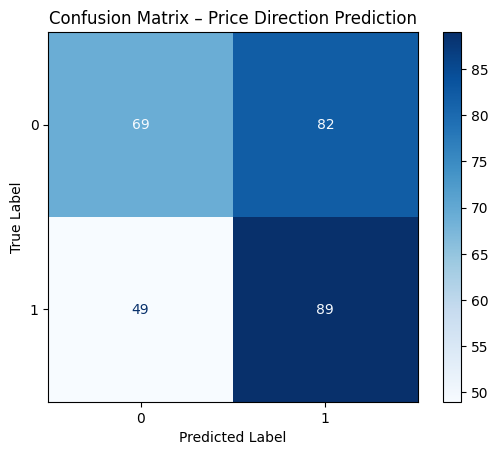

In [23]:
# =========================================================
# 1️⃣ Get model predictions
# =========================================================
# If binary classification (sigmoid output)
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities → class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# =========================================================
# 2️⃣ Generate confusion matrix
# =========================================================
cm = confusion_matrix(y_test, y_pred)
labels = np.unique(y_test)  # unique class labels (e.g., [0,1])

# =========================================================
# 3️⃣ Plot confusion matrix
# =========================================================
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix – Price Direction Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()


In [ ]:
# --- To Save ---
print("Saving model to HDF5 file...")
model.save('tesla_news_price_classifier_model.h5')
print("Model saved.")

# --- To Load it back later (in another script) ---
loaded_model = load_model('tesla_news_price_classifier_model.h5')

# Verify it's loaded correctly
loaded_model.summary()

Saving model to HDF5 file...
Model saved.


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,379 (52.27 KB)

 Trainable params: 12,897 (50.38 KB)

 Non-trainable params: 480 (1.88 KB)

 Optimizer params: 2 (12.00 B)